# Milestone 3: Complete Implementation

## Video Pipeline - Automated Optimizer with Assertions

**Authors:** Bhanu Prakash Vangala, Nolan Rink

---

### Contents:
1. **T1**: Pipeline Accuracy Definition
2. **T2**: Optimization Problem (INFaaS-based)
3. **T3**: Optimizer Implementation (Rule-based + ILP)
4. **T4**: Agentic Framework
5. **Assertions**: 6 Pipeline Assertions with Visualizations

---

In [29]:
# Imports
import torch
import numpy as np
import os
import time
import json
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
from collections import defaultdict, deque
from scipy.optimize import linear_sum_assignment
import warnings
warnings.filterwarnings('ignore')

# Check for PuLP
try:
    from pulp import LpProblem, LpVariable, LpMinimize, LpMaximize, lpSum, LpStatus, value, PULP_CBC_CMD, LpBinary
    PULP_AVAILABLE = True
except ImportError:
    PULP_AVAILABLE = False

print("=" * 80)
print("MILESTONE 3: COMPLETE IMPLEMENTATION")
print("=" * 80)
print(f"PuLP ILP Solver: {'Available' if PULP_AVAILABLE else 'Not Available'}")

MILESTONE 3: COMPLETE IMPLEMENTATION
PuLP ILP Solver: Available


In [30]:
# Setup
from ultralytics import YOLO

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Load model
model = YOLO('yolov8n.pt')
print("Model loaded: YOLOv8n")

# Dataset
sequence_folder = '../Dataset/MOT17/train/MOT17-04-DPM/img1'
if not os.path.exists(sequence_folder):
    sequence_folder = '../MOT17/train/MOT17-04-DPM/img1'
if not os.path.exists(sequence_folder):
    sequence_folder = 'Dataset/MOT17/train/MOT17-04-DPM/img1'
if not os.path.exists(sequence_folder):
    sequence_folder = '/app/Dataset/MOT17/train/MOT17-04-DPM/img1'

all_images = sorted([f for f in os.listdir(sequence_folder) if f.endswith('.jpg')])
NUM_FRAMES = 50
image_files = [os.path.join(sequence_folder, f) for f in all_images[:NUM_FRAMES]]
print(f"Dataset: {len(image_files)} frames from MOT17-04-DPM")

Device: cpu
Model loaded: YOLOv8n
Dataset: 50 frames from MOT17-04-DPM


In [31]:
# OC-SORT Tracker
class OCSort:
    def __init__(self, det_thresh=0.3, max_age=30, min_hits=3, iou_threshold=0.3):
        self.det_thresh = det_thresh
        self.max_age = max_age
        self.min_hits = min_hits
        self.iou_threshold = iou_threshold
        self.trackers = []
        self.frame_count = 0
        self.track_id_count = 1

    def reset(self):
        self.trackers = []
        self.frame_count = 0
        self.track_id_count = 1

    def update(self, detections):
        self.frame_count += 1
        if torch.is_tensor(detections):
            detections = detections.cpu().numpy()
        if len(detections) > 0:
            detections = detections[detections[:, 4] >= self.det_thresh]

        for tracker in self.trackers:
            tracker['age'] += 1

        if len(detections) > 0 and len(self.trackers) > 0:
            iou_matrix = np.zeros((len(detections), len(self.trackers)))
            for d, det in enumerate(detections):
                for t, tracker in enumerate(self.trackers):
                    iou_matrix[d, t] = self._iou(det[:4], tracker['bbox'])

            det_indices, track_indices = linear_sum_assignment(-iou_matrix)
            matched = [(d, t) for d, t in zip(det_indices, track_indices) if iou_matrix[d, t] >= self.iou_threshold]
            matched_dets = set(m[0] for m in matched)

            for det_idx, track_idx in matched:
                self.trackers[track_idx]['bbox'] = detections[det_idx][:4]
                self.trackers[track_idx]['score'] = detections[det_idx][4]
                self.trackers[track_idx]['age'] = 0
                self.trackers[track_idx]['hits'] += 1

            for d in range(len(detections)):
                if d not in matched_dets:
                    self.trackers.append({'id': self.track_id_count, 'bbox': detections[d][:4], 'score': detections[d][4], 'age': 0, 'hits': 1})
                    self.track_id_count += 1
        elif len(detections) > 0:
            for det in detections:
                self.trackers.append({'id': self.track_id_count, 'bbox': det[:4], 'score': det[4], 'age': 0, 'hits': 1})
                self.track_id_count += 1

        self.trackers = [t for t in self.trackers if t['age'] <= self.max_age]

        results = []
        for tracker in self.trackers:
            if tracker['hits'] >= self.min_hits or self.frame_count <= self.min_hits:
                results.append([tracker['bbox'][0], tracker['bbox'][1], tracker['bbox'][2], tracker['bbox'][3], tracker['id'], tracker['score']])
        return results

    def _iou(self, box1, box2):
        x1, y1 = max(box1[0], box2[0]), max(box1[1], box2[1])
        x2, y2 = min(box1[2], box2[2]), min(box1[3], box2[3])
        if x2 <= x1 or y2 <= y1:
            return 0.0
        inter = (x2 - x1) * (y2 - y1)
        area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
        area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
        return inter / (area1 + area2 - inter + 1e-6)

print("OC-SORT Tracker defined!")

OC-SORT Tracker defined!


---
## T1: Pipeline Accuracy Definition

### What is Pipeline Accuracy?

Pipeline accuracy is a **composite metric** that measures the overall quality of a video analytics pipeline. Unlike single-task metrics (e.g., mAP for detection), pipeline accuracy captures the **end-to-end performance** across multiple stages: detection, tracking, and temporal consistency.

### The Formula

```
A_pipeline = 0.4 × A_detection + 0.4 × A_tracking + 0.2 × A_consistency
```

### Variable Definitions

| Variable | Symbol | Description |
|----------|--------|-------------|
| **A_pipeline** | Combined accuracy | Overall pipeline quality score (0-1) |
| **A_detection** | Detection accuracy | Quality of object detection (confidence, stability) |
| **A_tracking** | Tracking accuracy | Quality of object tracking (ID consistency, continuity) |
| **A_consistency** | Consistency accuracy | Temporal coherence (motion smoothness, size stability) |

### Why These Weights? (0.4, 0.4, 0.2)

The weight distribution reflects the **relative importance** of each component in a video analytics pipeline:

1. **Detection (0.4 = 40%)**: Detection is the foundation—if objects aren't detected, they can't be tracked. High weight because errors here propagate downstream.

2. **Tracking (0.4 = 40%)**: Tracking is equally critical for video analytics. Maintaining correct object identities across frames is essential for counting, trajectory analysis, and behavior understanding.

3. **Consistency (0.2 = 20%)**: Lower weight because it's a **quality refinement** metric. A pipeline can be functional with some temporal jitter, but inconsistency affects user experience and downstream analytics quality.

**Rationale**: Detection and tracking are "must-have" capabilities (hence 80% combined), while consistency is a "nice-to-have" quality enhancement (20%).

---

In [32]:
print("=" * 80)
print("T1: PIPELINE ACCURACY DEFINITION")
print("=" * 80)

@dataclass
class AccuracyConfig:
    detection_weight: float = 0.4
    tracking_weight: float = 0.4
    consistency_weight: float = 0.2

class PipelineAccuracyCalculator:
    """
    Calculates combined pipeline accuracy.
    
    Formula: A_pipeline = 0.4 * A_detection + 0.4 * A_tracking + 0.2 * A_consistency
    """
    
    def __init__(self, config=None):
        self.config = config or AccuracyConfig()
    
    def calculate_detection_accuracy(self, detections_per_frame, confidences):
        if not confidences:
            return {'mean_confidence': 0, 'stability': 0, 'high_conf_ratio': 0, 'accuracy': 0}
        
        mean_conf = np.mean(confidences)
        high_conf = sum(1 for c in confidences if c >= 0.5) / len(confidences)
        
        if len(detections_per_frame) > 1:
            stability = max(0, 1 - (np.std(detections_per_frame) / (np.mean(detections_per_frame) + 1e-6)))
        else:
            stability = 1.0
        
        accuracy = 0.4 * mean_conf + 0.3 * stability + 0.3 * high_conf
        
        return {
            'mean_confidence': mean_conf,
            'stability': stability,
            'high_conf_ratio': high_conf,
            'accuracy': accuracy
        }
    
    def calculate_tracking_accuracy(self, tracked_objects):
        if not tracked_objects:
            return {'continuity': 0, 'id_consistency': 0, 'coverage': 0, 'accuracy': 0}
        
        tracks = defaultdict(list)
        for obj in tracked_objects:
            tracks[obj['track_id']].append(obj)
        
        track_lengths = [len(t) for t in tracks.values()]
        max_frames = max(obj['frame_id'] for obj in tracked_objects)
        continuity = min(1.0, np.mean(track_lengths) / max(10, max_frames * 0.5))
        
        valid = total = 0
        for tid, tdata in tracks.items():
            tdata.sort(key=lambda x: x['frame_id'])
            for i in range(1, len(tdata)):
                prev, curr = tdata[i-1], tdata[i]
                dist = np.sqrt(
                    ((curr['bbox'][0] + curr['bbox'][2]/2) - (prev['bbox'][0] + prev['bbox'][2]/2))**2 +
                    ((curr['bbox'][1] + curr['bbox'][3]/2) - (prev['bbox'][1] + prev['bbox'][3]/2))**2
                )
                total += 1
                if dist <= 100:
                    valid += 1
        id_consistency = valid / total if total > 0 else 0
        
        coverage = len(set(obj['frame_id'] for obj in tracked_objects)) / max_frames
        
        accuracy = 0.3 * continuity + 0.4 * id_consistency + 0.3 * coverage
        
        return {
            'continuity': continuity,
            'id_consistency': id_consistency,
            'coverage': coverage,
            'accuracy': accuracy
        }
    
    def calculate_consistency_accuracy(self, tracked_objects):
        if not tracked_objects:
            return {'motion_smoothness': 0, 'size_stability': 0, 'accuracy': 0}
        
        tracks = defaultdict(list)
        for obj in tracked_objects:
            tracks[obj['track_id']].append(obj)
        
        motion_scores = []
        size_scores = []
        
        for tid, tdata in tracks.items():
            if len(tdata) < 3:
                continue
            tdata.sort(key=lambda x: x['frame_id'])
            velocities = []
            sizes = []
            
            for i in range(1, len(tdata)):
                prev, curr = tdata[i-1], tdata[i]
                velocity = np.sqrt(
                    ((curr['bbox'][0] + curr['bbox'][2]/2) - (prev['bbox'][0] + prev['bbox'][2]/2))**2 +
                    ((curr['bbox'][1] + curr['bbox'][3]/2) - (prev['bbox'][1] + prev['bbox'][3]/2))**2
                )
                velocities.append(velocity)
                sizes.append(curr['bbox'][2] * curr['bbox'][3])
            
            if len(velocities) > 1:
                motion_scores.append(max(0, 1 - (np.std(velocities) / (np.mean(velocities) + 10))))
            if len(sizes) > 1:
                size_scores.append(max(0, 1 - (np.std(sizes) / (np.mean(sizes) + 1e-6))))
        
        motion_smoothness = np.mean(motion_scores) if motion_scores else 0.5
        size_stability = np.mean(size_scores) if size_scores else 0.5
        accuracy = 0.5 * motion_smoothness + 0.5 * size_stability
        
        return {
            'motion_smoothness': motion_smoothness,
            'size_stability': size_stability,
            'accuracy': accuracy
        }
    
    def calculate_combined(self, detections_per_frame, confidences, tracked_objects):
        det = self.calculate_detection_accuracy(detections_per_frame, confidences)
        track = self.calculate_tracking_accuracy(tracked_objects)
        consist = self.calculate_consistency_accuracy(tracked_objects)
        
        combined = (
            self.config.detection_weight * det['accuracy'] +
            self.config.tracking_weight * track['accuracy'] +
            self.config.consistency_weight * consist['accuracy']
        )
        
        return {
            'detection': det,
            'tracking': track,
            'consistency': consist,
            'combined_accuracy': combined
        }

print("""
PIPELINE ACCURACY FORMULA:
  A_pipeline = 0.4 * A_detection + 0.4 * A_tracking + 0.2 * A_consistency

DETECTION ACCURACY:
  = 0.4 * mean_confidence + 0.3 * stability + 0.3 * high_conf_ratio

TRACKING ACCURACY:
  = 0.3 * continuity + 0.4 * id_consistency + 0.3 * coverage

CONSISTENCY ACCURACY:
  = 0.5 * motion_smoothness + 0.5 * size_stability
""")

T1: PIPELINE ACCURACY DEFINITION

PIPELINE ACCURACY FORMULA:
  A_pipeline = 0.4 * A_detection + 0.4 * A_tracking + 0.2 * A_consistency

DETECTION ACCURACY:
  = 0.4 * mean_confidence + 0.3 * stability + 0.3 * high_conf_ratio

TRACKING ACCURACY:
  = 0.3 * continuity + 0.4 * id_consistency + 0.3 * coverage

CONSISTENCY ACCURACY:
  = 0.5 * motion_smoothness + 0.5 * size_stability



---
## Pipeline Assertions

### What are Assertions?

Assertions are **runtime validation checks** that verify the pipeline's output meets expected behavioral constraints. They act as "sanity checks" to catch anomalies, bugs, or quality degradation during video processing.

### Why are Assertions Important?

1. **Quality Assurance**: Detect when the pipeline produces unrealistic or erroneous results
2. **Debugging**: Pinpoint specific frames/tracks where issues occur
3. **Monitoring**: Enable real-time alerting in production systems
4. **Reproducibility**: Ensure consistent behavior across different runs/environments

---

## The 6 Pipeline Assertions

### Assertion 1: Distance Assertion
**Rule**: Objects with the same track ID must not move >100 pixels between consecutive frames

| Aspect | Description |
|--------|-------------|
| **What it checks** | Movement distance of tracked objects between consecutive frames |
| **Threshold** | 100 pixels maximum displacement |
| **Why it matters** | Objects in video move at physically plausible speeds. A 100px jump in 1 frame (at 30fps) suggests tracking error or ID switch |
| **Failure indicates** | Track ID swap, detection flickering, or tracker losing and re-acquiring object |

### Assertion 2: Bounding Box Size Assertion
**Rule**: Bounding box area shouldn't change >50% between consecutive frames

| Aspect | Description |
|--------|-------------|
| **What it checks** | Relative change in bounding box area between frames |
| **Threshold** | 50% maximum size change |
| **Why it matters** | Objects don't suddenly grow or shrink. Smooth size changes indicate consistent detection |
| **Failure indicates** | Partial occlusion, detection switching between objects, or detector instability |

### Assertion 3: Confidence Threshold Assertion
**Rule**: All tracked detections must have confidence ≥ 0.3

| Aspect | Description |
|--------|-------------|
| **What it checks** | Detector confidence score for each tracked object |
| **Threshold** | 0.3 minimum confidence |
| **Why it matters** | Low-confidence detections are unreliable and may be false positives |
| **Failure indicates** | Detector uncertainty, possible false positive, or occluded object |

### Assertion 4: Track Continuity Assertion
**Rule**: Tracks shouldn't have gaps > 5 frames

| Aspect | Description |
|--------|-------------|
| **What it checks** | Frame gaps in track appearance (track disappears then reappears) |
| **Threshold** | 5 frames maximum gap |
| **Why it matters** | Real objects don't teleport. Brief gaps are acceptable (occlusion), long gaps suggest tracking failure |
| **Failure indicates** | Track fragmentation, prolonged occlusion, or object leaving/re-entering scene |

### Assertion 5: Detection Stability Assertion
**Rule**: Detection count shouldn't vary >50% between consecutive frames

| Aspect | Description |
|--------|-------------|
| **What it checks** | Change in total number of detections between frames |
| **Threshold** | 50% maximum variation |
| **Why it matters** | Scene content changes gradually. Sudden detection count changes suggest detector instability |
| **Failure indicates** | Lighting changes, camera motion, detector flickering, or scene transition |

### Assertion 6: IoU Consistency Assertion
**Rule**: Same track's bounding box IoU ≥ 0.3 between consecutive frames

| Aspect | Description |
|--------|-------------|
| **What it checks** | Intersection over Union between same track's boxes in consecutive frames |
| **Threshold** | 0.3 minimum IoU |
| **Why it matters** | Consecutive detections of same object should overlap significantly |
| **Failure indicates** | Rapid object motion, tracking drift, or detection jitter |

---

In [33]:
@dataclass
class AssertionResult:
    name: str
    passed: bool
    frame_id: int
    track_id: int
    details: str
    value: float = 0.0
    threshold: float = 0.0

class BaseAssertion:
    def __init__(self, name: str):
        self.name = name
        self.results: List[AssertionResult] = []
        self.violations: List[AssertionResult] = []
    
    def get_pass_rate(self) -> float:
        if not self.results:
            return 0.0
        return sum(1 for r in self.results if r.passed) / len(self.results)
    
    def get_values_by_track(self) -> Dict[int, List[Tuple[int, float]]]:
        """Get (frame_id, value) pairs grouped by track_id"""
        by_track = defaultdict(list)
        for r in self.results:
            by_track[r.track_id].append((r.frame_id, r.value))
        return by_track

print("Base Assertion class defined!")

Base Assertion class defined!


In [34]:
class DistanceAssertion(BaseAssertion):
    """Assertion 1: Objects must not move >100px between consecutive frames"""
    def __init__(self, max_distance: float = 100.0):
        super().__init__("Distance Assertion")
        self.max_distance = max_distance
        self.track_history = defaultdict(list)

    def check(self, frame_id: int, tracks: List, **kwargs):
        for track in tracks:
            track_id = int(track[4])
            bbox = np.array(track[:4])
            center = np.array([(bbox[0] + bbox[2]) / 2, (bbox[1] + bbox[3]) / 2])

            if track_id in self.track_history and len(self.track_history[track_id]) > 0:
                last_frame, last_center = self.track_history[track_id][-1]
                if frame_id - last_frame == 1:
                    distance = np.linalg.norm(center - last_center)
                    passed = distance <= self.max_distance
                    result = AssertionResult(
                        name=self.name, passed=passed, frame_id=frame_id, track_id=track_id,
                        details=f"Track {track_id}: {distance:.1f}px",
                        value=distance, threshold=self.max_distance
                    )
                    self.results.append(result)
                    if not passed:
                        self.violations.append(result)

            self.track_history[track_id].append((frame_id, center))

print("Distance Assertion defined (threshold: 100px)")

Distance Assertion defined (threshold: 100px)


In [35]:
class BoundingBoxSizeAssertion(BaseAssertion):
    """Assertion 2: Bounding box size change <= 50% between frames"""
    def __init__(self, max_change_ratio: float = 0.5):
        super().__init__("BBox Size Assertion")
        self.max_change_ratio = max_change_ratio
        self.track_sizes = defaultdict(list)

    def check(self, frame_id: int, tracks: List, **kwargs):
        for track in tracks:
            track_id = int(track[4])
            bbox = track[:4]
            area = (bbox[2] - bbox[0]) * (bbox[3] - bbox[1])

            if track_id in self.track_sizes and len(self.track_sizes[track_id]) > 0:
                last_frame, last_area = self.track_sizes[track_id][-1]
                if frame_id - last_frame == 1 and last_area > 0:
                    change_ratio = abs(area - last_area) / last_area
                    passed = change_ratio <= self.max_change_ratio
                    result = AssertionResult(
                        name=self.name, passed=passed, frame_id=frame_id, track_id=track_id,
                        details=f"Track {track_id}: {change_ratio*100:.1f}%",
                        value=change_ratio, threshold=self.max_change_ratio
                    )
                    self.results.append(result)
                    if not passed:
                        self.violations.append(result)

            self.track_sizes[track_id].append((frame_id, area))

print("BBox Size Assertion defined (threshold: 50%)")

BBox Size Assertion defined (threshold: 50%)


In [36]:
class ConfidenceThresholdAssertion(BaseAssertion):
    """Assertion 3: All detections must have confidence >= 0.3"""
    def __init__(self, min_confidence: float = 0.3):
        super().__init__("Confidence Assertion")
        self.min_confidence = min_confidence

    def check(self, frame_id: int, tracks: List, **kwargs):
        for track in tracks:
            track_id = int(track[4])
            confidence = float(track[5])
            passed = confidence >= self.min_confidence
            result = AssertionResult(
                name=self.name, passed=passed, frame_id=frame_id, track_id=track_id,
                details=f"Track {track_id}: conf={confidence:.3f}",
                value=confidence, threshold=self.min_confidence
            )
            self.results.append(result)
            if not passed:
                self.violations.append(result)

print("Confidence Assertion defined (threshold: 0.3)")

Confidence Assertion defined (threshold: 0.3)


In [37]:
class TrackContinuityAssertion(BaseAssertion):
    """Assertion 4: Tracks shouldn't have gaps > 5 frames"""
    def __init__(self, max_gap: int = 5):
        super().__init__("Track Continuity Assertion")
        self.max_gap = max_gap
        self.track_frames = defaultdict(list)

    def check(self, frame_id: int, tracks: List, **kwargs):
        for track in tracks:
            track_id = int(track[4])
            if track_id in self.track_frames and len(self.track_frames[track_id]) > 0:
                last_frame = self.track_frames[track_id][-1]
                gap = frame_id - last_frame - 1
                if gap > 0:
                    passed = gap <= self.max_gap
                    result = AssertionResult(
                        name=self.name, passed=passed, frame_id=frame_id, track_id=track_id,
                        details=f"Track {track_id}: gap={gap} frames",
                        value=gap, threshold=self.max_gap
                    )
                    self.results.append(result)
                    if not passed:
                        self.violations.append(result)
            self.track_frames[track_id].append(frame_id)

print("Track Continuity Assertion defined (threshold: 5 frames)")

Track Continuity Assertion defined (threshold: 5 frames)


In [38]:
class DetectionStabilityAssertion(BaseAssertion):
    """Assertion 5: Detection count change <= 50% between frames"""
    def __init__(self, max_variation: float = 0.5):
        super().__init__("Detection Stability Assertion")
        self.max_variation = max_variation
        self.prev_count = None
        self.prev_frame = None

    def check(self, frame_id: int, tracks: List, **kwargs):
        count = len(tracks)
        if self.prev_count is not None and self.prev_frame == frame_id - 1:
            if self.prev_count > 0:
                variation = abs(count - self.prev_count) / self.prev_count
            else:
                variation = 0 if count == 0 else 1.0
            
            passed = variation <= self.max_variation
            result = AssertionResult(
                name=self.name, passed=passed, frame_id=frame_id, track_id=0,
                details=f"Count: {self.prev_count}->{count} ({variation*100:.1f}%)",
                value=variation, threshold=self.max_variation
            )
            self.results.append(result)
            if not passed:
                self.violations.append(result)
        
        self.prev_count = count
        self.prev_frame = frame_id

print("Detection Stability Assertion defined (threshold: 50%)")

Detection Stability Assertion defined (threshold: 50%)


In [39]:
class IoUConsistencyAssertion(BaseAssertion):
    """Assertion 6: Same track's IoU >= 0.3 between consecutive frames"""
    def __init__(self, min_iou: float = 0.3):
        super().__init__("IoU Consistency Assertion")
        self.min_iou = min_iou
        self.track_bboxes = defaultdict(list)

    def _iou(self, box1, box2):
        x1, y1 = max(box1[0], box2[0]), max(box1[1], box2[1])
        x2, y2 = min(box1[2], box2[2]), min(box1[3], box2[3])
        if x2 <= x1 or y2 <= y1:
            return 0.0
        inter = (x2 - x1) * (y2 - y1)
        area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
        area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
        return inter / (area1 + area2 - inter + 1e-6)

    def check(self, frame_id: int, tracks: List, **kwargs):
        for track in tracks:
            track_id = int(track[4])
            bbox = np.array(track[:4])

            if track_id in self.track_bboxes and len(self.track_bboxes[track_id]) > 0:
                last_frame, last_bbox = self.track_bboxes[track_id][-1]
                if frame_id - last_frame == 1:
                    iou = self._iou(bbox, last_bbox)
                    passed = iou >= self.min_iou
                    result = AssertionResult(
                        name=self.name, passed=passed, frame_id=frame_id, track_id=track_id,
                        details=f"Track {track_id}: IoU={iou:.3f}",
                        value=iou, threshold=self.min_iou
                    )
                    self.results.append(result)
                    if not passed:
                        self.violations.append(result)

            self.track_bboxes[track_id].append((frame_id, bbox))

print("IoU Consistency Assertion defined (threshold: 0.3)")

IoU Consistency Assertion defined (threshold: 0.3)


---
## Run Pipeline with All Assertions

---

In [40]:
print("\n" + "=" * 80)
print("RUNNING PIPELINE WITH ASSERTIONS")
print("=" * 80)

# Initialize
tracker = OCSort()
acc_calc = PipelineAccuracyCalculator()

# Initialize assertions
assertions = {
    'distance': DistanceAssertion(max_distance=100.0),
    'bbox_size': BoundingBoxSizeAssertion(max_change_ratio=0.5),
    'confidence': ConfidenceThresholdAssertion(min_confidence=0.3),
    'continuity': TrackContinuityAssertion(max_gap=5),
    'stability': DetectionStabilityAssertion(max_variation=0.5),
    'iou': IoUConsistencyAssertion(min_iou=0.3)
}

# Data storage
all_frame_data = []
detections_per_frame = []
tracks_per_frame = []
all_confidences = []
tracked_objects = []

# Run pipeline
for frame_idx, img_path in enumerate(image_files):
    image = Image.open(img_path).convert("RGB")
    results = model(image, verbose=False)

    frame_dets = []
    for result in results:
        boxes = result.boxes
        if boxes is not None:
            for i, class_id in enumerate(boxes.cls):
                if int(class_id) == 0 and boxes.conf[i] >= 0.3:
                    box = boxes.xyxy[i].cpu().numpy()
                    conf = float(boxes.conf[i])
                    frame_dets.append([box[0], box[1], box[2], box[3], conf])
                    all_confidences.append(conf)

    detections_per_frame.append(len(frame_dets))

    if frame_dets:
        det_tensor = torch.tensor(np.array(frame_dets))
        tracks = tracker.update(det_tensor)
    else:
        tracks = []

    tracks_per_frame.append(len(tracks))

    # Store tracked objects for accuracy
    for track in tracks:
        tracked_objects.append({
            'frame_id': frame_idx + 1,
            'track_id': int(track[4]),
            'bbox': [track[0], track[1], track[2]-track[0], track[3]-track[1]],
            'confidence': float(track[5])
        })

    # Run all assertions
    for assertion in assertions.values():
        assertion.check(frame_idx, tracks)

    all_frame_data.append({
        'frame_idx': frame_idx,
        'image_path': img_path,
        'detections': frame_dets,
        'tracks': tracks,
        'image': np.array(image)
    })

    print(f"\rFrame {frame_idx+1}/{len(image_files)} - Det: {len(frame_dets)}, Tracks: {len(tracks)}", end="")

print("\n" + "=" * 80)
print("Pipeline complete!")


RUNNING PIPELINE WITH ASSERTIONS
Frame 50/50 - Det: 20, Tracks: 26
Pipeline complete!


In [41]:
# Calculate T1 Accuracy
accuracy = acc_calc.calculate_combined(detections_per_frame, all_confidences, tracked_objects)

print("\n" + "=" * 80)
print("T1: PIPELINE ACCURACY RESULTS")
print("=" * 80)
print(f"\nDetection Accuracy:  {accuracy['detection']['accuracy']:.4f}")
print(f"Tracking Accuracy:   {accuracy['tracking']['accuracy']:.4f}")
print(f"Consistency Accuracy: {accuracy['consistency']['accuracy']:.4f}")
print(f"\nCOMBINED ACCURACY: {accuracy['combined_accuracy']:.4f}")


T1: PIPELINE ACCURACY RESULTS

Detection Accuracy:  0.7120
Tracking Accuracy:   1.0000
Consistency Accuracy: 0.8795

COMBINED ACCURACY: 0.8607


In [42]:
# Print Assertion Summary
print("\n" + "=" * 80)
print("ASSERTION RESULTS SUMMARY")
print("=" * 80)

print(f"\n{'Assertion':<30} {'Total':<10} {'Passed':<10} {'Failed':<10} {'Pass Rate':<12} {'Status'}")
print("-" * 85)

for name, assertion in assertions.items():
    total = len(assertion.results)
    passed = sum(1 for r in assertion.results if r.passed)
    failed = len(assertion.violations)
    rate = assertion.get_pass_rate() * 100
    status = "PASS" if rate >= 90 else "WARN" if rate >= 70 else "FAIL"
    print(f"{assertion.name:<30} {total:<10} {passed:<10} {failed:<10} {rate:<12.1f}% [{status}]")

total_all = sum(len(a.results) for a in assertions.values())
passed_all = sum(sum(1 for r in a.results if r.passed) for a in assertions.values())
print("-" * 85)
print(f"{'OVERALL':<30} {total_all:<10} {passed_all:<10} {total_all-passed_all:<10} {passed_all/total_all*100:.1f}%")


ASSERTION RESULTS SUMMARY

Assertion                      Total      Passed     Failed     Pass Rate    Status
-------------------------------------------------------------------------------------
Distance Assertion             1191       1191       0          100.0       % [PASS]
BBox Size Assertion            1191       1189       2          99.8        % [PASS]
Confidence Assertion           1221       1221       0          100.0       % [PASS]
Track Continuity Assertion     3          3          0          100.0       % [PASS]
Detection Stability Assertion  49         49         0          100.0       % [PASS]
IoU Consistency Assertion      1191       1191       0          100.0       % [PASS]
-------------------------------------------------------------------------------------
OVERALL                        4846       4844       2          100.0%


---
## Assertion 1: Distance Assertion Visualization

### Rule
Objects with the same track ID must not move more than **100 pixels** between consecutive frames.

### Significance
- **Physical Plausibility**: At 30fps, 100px/frame = 3000px/second movement, which is already very fast for typical video
- **Tracking Quality**: Large jumps indicate the tracker may have lost the object and re-assigned the same ID to a different object
- **Use Case**: Essential for trajectory analysis, behavior prediction, and counting applications

### Visualization
- **Left Panel**: Track trajectories overlaid on video frame (circle=start, square=end)
- **Right Panel**: Distance moved per track per frame, with 100px threshold line

---

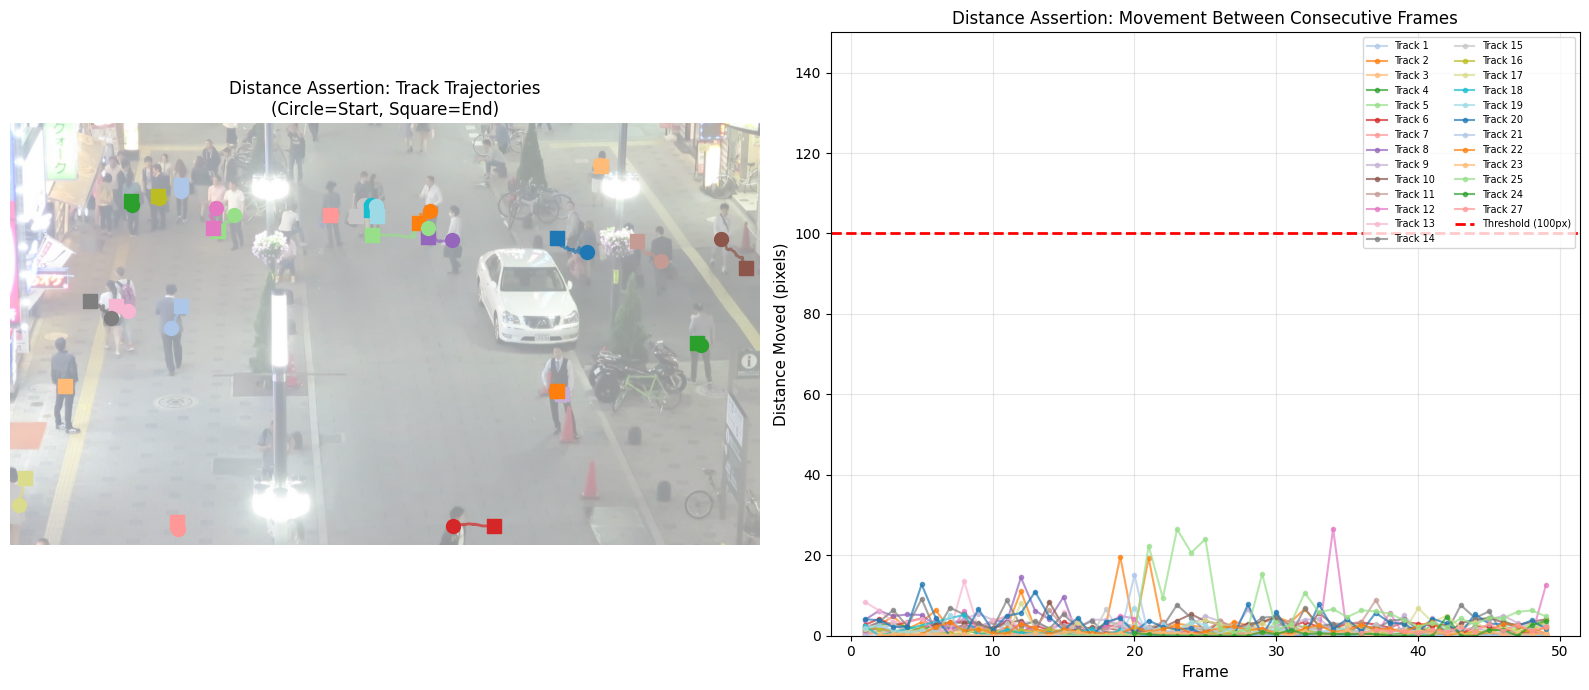

Saved: assertion_1_distance.png


In [43]:
# Distance Assertion Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Track trajectories on image
ax1 = axes[0]
ax1.imshow(all_frame_data[0]['image'], alpha=0.5)

colors = plt.cm.tab20(np.linspace(0, 1, 20))
track_trajectories = defaultdict(list)
for frame_data in all_frame_data:
    for track in frame_data['tracks']:
        track_id = int(track[4])
        center_x = (track[0] + track[2]) / 2
        center_y = (track[1] + track[3]) / 2
        track_trajectories[track_id].append((frame_data['frame_idx'], center_x, center_y))

for track_id, trajectory in track_trajectories.items():
    if len(trajectory) > 5:
        x = [t[1] for t in trajectory]
        y = [t[2] for t in trajectory]
        color = colors[track_id % 20]
        ax1.plot(x, y, '-', color=color, linewidth=2, alpha=0.7)
        ax1.scatter(x[0], y[0], color=color, s=100, marker='o', zorder=5)
        ax1.scatter(x[-1], y[-1], color=color, s=100, marker='s', zorder=5)

ax1.set_title('Distance Assertion: Track Trajectories\n(Circle=Start, Square=End)', fontsize=12)
ax1.axis('off')

# Right: Distance values per track over frames
ax2 = axes[1]
by_track = assertions['distance'].get_values_by_track()
for track_id, values in by_track.items():
    if len(values) > 3:
        frames = [v[0] for v in values]
        dists = [v[1] for v in values]
        color = colors[track_id % 20]
        ax2.plot(frames, dists, '-o', color=color, alpha=0.7, markersize=3, label=f'Track {track_id}')

ax2.axhline(y=100, color='red', linestyle='--', linewidth=2, label='Threshold (100px)')
ax2.set_xlabel('Frame', fontsize=11)
ax2.set_ylabel('Distance Moved (pixels)', fontsize=11)
ax2.set_title('Distance Assertion: Movement Between Consecutive Frames', fontsize=12)
ax2.legend(loc='upper right', fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, max(150, max(r.value for r in assertions['distance'].results) * 1.1))

plt.tight_layout()
plt.savefig('assertion_1_distance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: assertion_1_distance.png")

---
## Assertion 2: Bounding Box Size Assertion Visualization

### Rule
Bounding box area shouldn't change more than **50%** between consecutive frames.

### Significance
- **Physical Reality**: Objects don't suddenly double or halve in size—perspective changes are gradual
- **Detection Stability**: Large size changes suggest the detector is unstable or switching between different objects
- **Use Case**: Critical for size-based analytics (vehicle classification, crowd density estimation)

### Visualization
- **Left Panel**: Bounding boxes with area labels on a sample frame
- **Right Panel**: Percentage size change per track per frame, with 50% threshold line

---

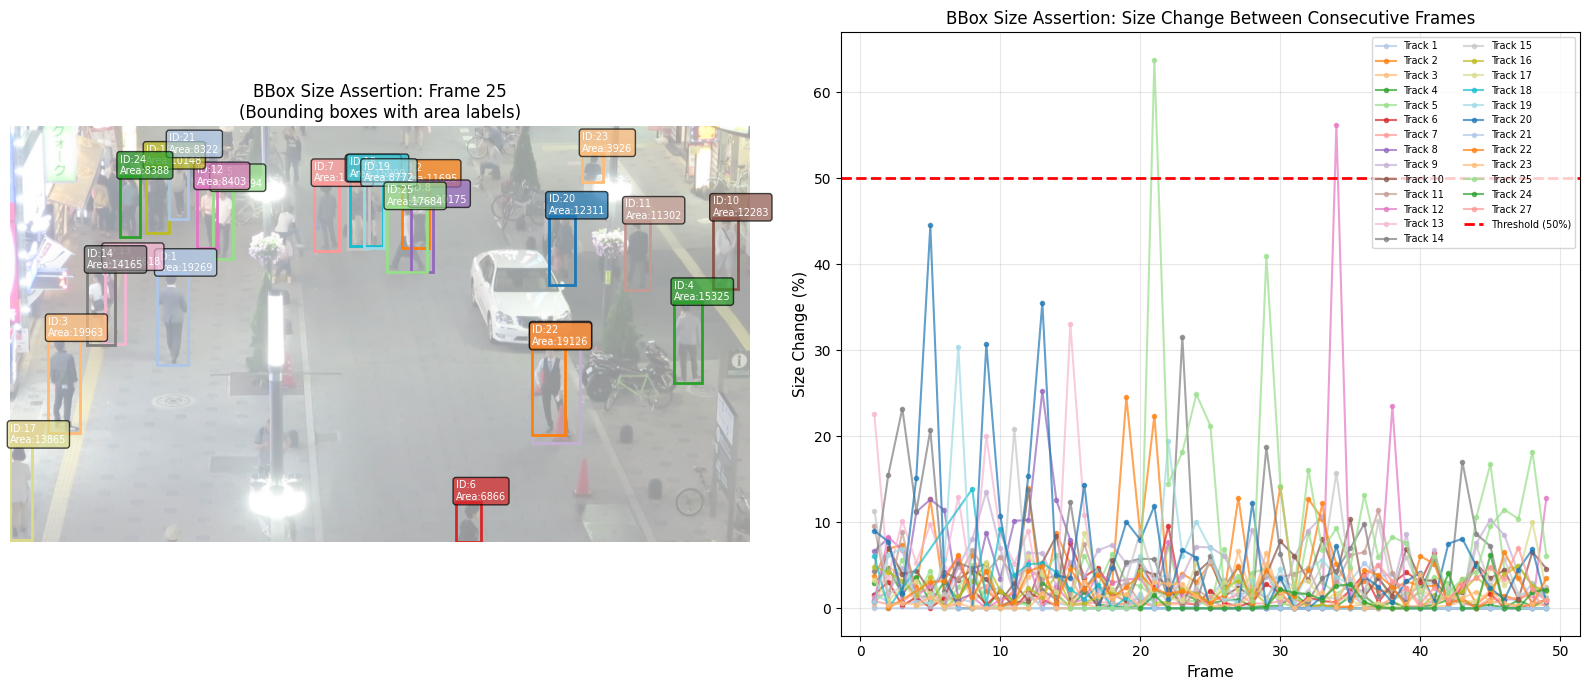

Saved: assertion_2_bbox_size.png


In [44]:
# BBox Size Assertion Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Show tracks with size indicated by marker size
ax1 = axes[0]
ax1.imshow(all_frame_data[len(all_frame_data)//2]['image'], alpha=0.5)

# Draw bboxes from middle frame with size annotation
mid_frame = all_frame_data[len(all_frame_data)//2]
for track in mid_frame['tracks']:
    x1, y1, x2, y2, track_id, conf = track
    area = (x2 - x1) * (y2 - y1)
    color = colors[int(track_id) % 20]
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor=color, facecolor='none')
    ax1.add_patch(rect)
    ax1.text(x1, y1-5, f'ID:{int(track_id)}\nArea:{area:.0f}', color='white', fontsize=7,
             bbox=dict(boxstyle='round', facecolor=color, alpha=0.7))

ax1.set_title(f'BBox Size Assertion: Frame {len(all_frame_data)//2}\n(Bounding boxes with area labels)', fontsize=12)
ax1.axis('off')

# Right: Size change percentage per track over frames
ax2 = axes[1]
by_track = assertions['bbox_size'].get_values_by_track()
for track_id, values in by_track.items():
    if len(values) > 3:
        frames = [v[0] for v in values]
        changes = [v[1] * 100 for v in values]  # Convert to percentage
        color = colors[track_id % 20]
        ax2.plot(frames, changes, '-o', color=color, alpha=0.7, markersize=3, label=f'Track {track_id}')

ax2.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Threshold (50%)')
ax2.set_xlabel('Frame', fontsize=11)
ax2.set_ylabel('Size Change (%)', fontsize=11)
ax2.set_title('BBox Size Assertion: Size Change Between Consecutive Frames', fontsize=12)
ax2.legend(loc='upper right', fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('assertion_2_bbox_size.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: assertion_2_bbox_size.png")

---
## Assertion 3: Confidence Threshold Assertion Visualization

### Rule
All tracked detections must have confidence score ≥ **0.3**.

### Significance
- **False Positive Filtering**: Low-confidence detections are often false positives (noise, background objects)
- **Reliability**: Downstream analytics depend on reliable detections; uncertain detections contaminate results
- **Use Case**: Essential for any application requiring accurate counts or object identification

### Visualization
- **Left Panel**: Detections color-coded by confidence (Green ≥ 0.7, Yellow ≥ 0.5, Orange ≥ 0.3)
- **Right Panel**: Confidence scores per track over time, with 0.3 threshold line

---

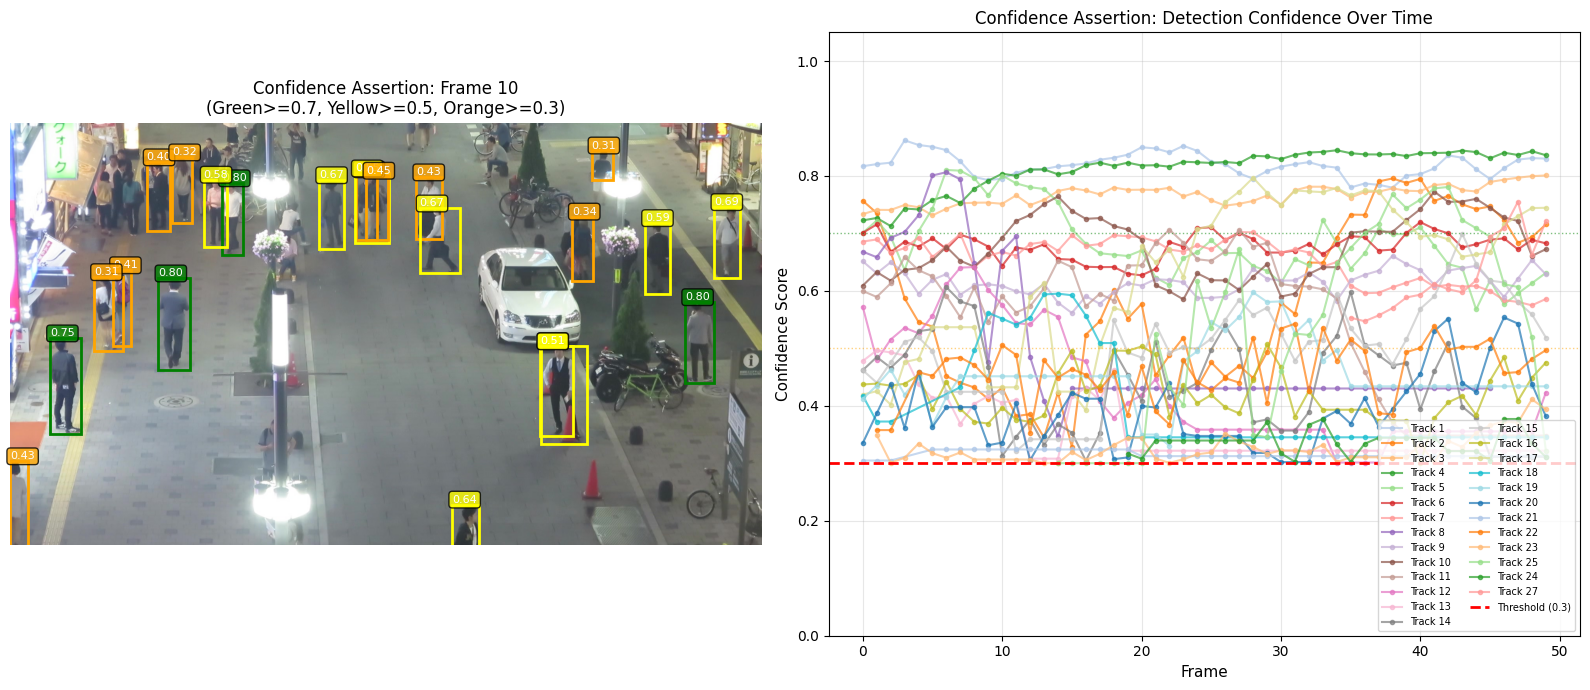

Saved: assertion_3_confidence.png


In [45]:
# Confidence Assertion Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Show frame with confidence color-coded
ax1 = axes[0]
frame_idx = 10
ax1.imshow(all_frame_data[frame_idx]['image'])

for track in all_frame_data[frame_idx]['tracks']:
    x1, y1, x2, y2, track_id, conf = track
    # Color by confidence: green=high, yellow=medium, red=low
    if conf >= 0.7:
        color = 'green'
    elif conf >= 0.5:
        color = 'yellow'
    else:
        color = 'orange'
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor=color, facecolor='none')
    ax1.add_patch(rect)
    ax1.text(x1, y1-5, f'{conf:.2f}', color='white', fontsize=8,
             bbox=dict(boxstyle='round', facecolor=color, alpha=0.8))

ax1.set_title(f'Confidence Assertion: Frame {frame_idx}\n(Green>=0.7, Yellow>=0.5, Orange>=0.3)', fontsize=12)
ax1.axis('off')

# Right: Confidence values per track over frames
ax2 = axes[1]
by_track = assertions['confidence'].get_values_by_track()
for track_id, values in by_track.items():
    if len(values) > 3:
        frames = [v[0] for v in values]
        confs = [v[1] for v in values]
        color = colors[track_id % 20]
        ax2.plot(frames, confs, '-o', color=color, alpha=0.7, markersize=3, label=f'Track {track_id}')

ax2.axhline(y=0.3, color='red', linestyle='--', linewidth=2, label='Threshold (0.3)')
ax2.axhline(y=0.5, color='orange', linestyle=':', linewidth=1, alpha=0.5)
ax2.axhline(y=0.7, color='green', linestyle=':', linewidth=1, alpha=0.5)
ax2.set_xlabel('Frame', fontsize=11)
ax2.set_ylabel('Confidence Score', fontsize=11)
ax2.set_title('Confidence Assertion: Detection Confidence Over Time', fontsize=12)
ax2.legend(loc='lower right', fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('assertion_3_confidence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: assertion_3_confidence.png")

---
## Assertion 4: Track Continuity Assertion Visualization

### Rule
Tracks shouldn't have gaps greater than **5 frames**.

### Significance
- **Track Integrity**: Long gaps suggest track fragmentation—the same object gets multiple IDs
- **Occlusion Handling**: Brief gaps (≤5 frames) are acceptable during occlusion; longer gaps indicate failure
- **Use Case**: Critical for accurate object counting, dwell time analysis, and re-identification

### Visualization
- **Left Panel**: Track presence heatmap (rows=tracks, columns=frames, green=present)
- **Right Panel**: Gap sizes when tracks reappear, with 5-frame threshold line

---

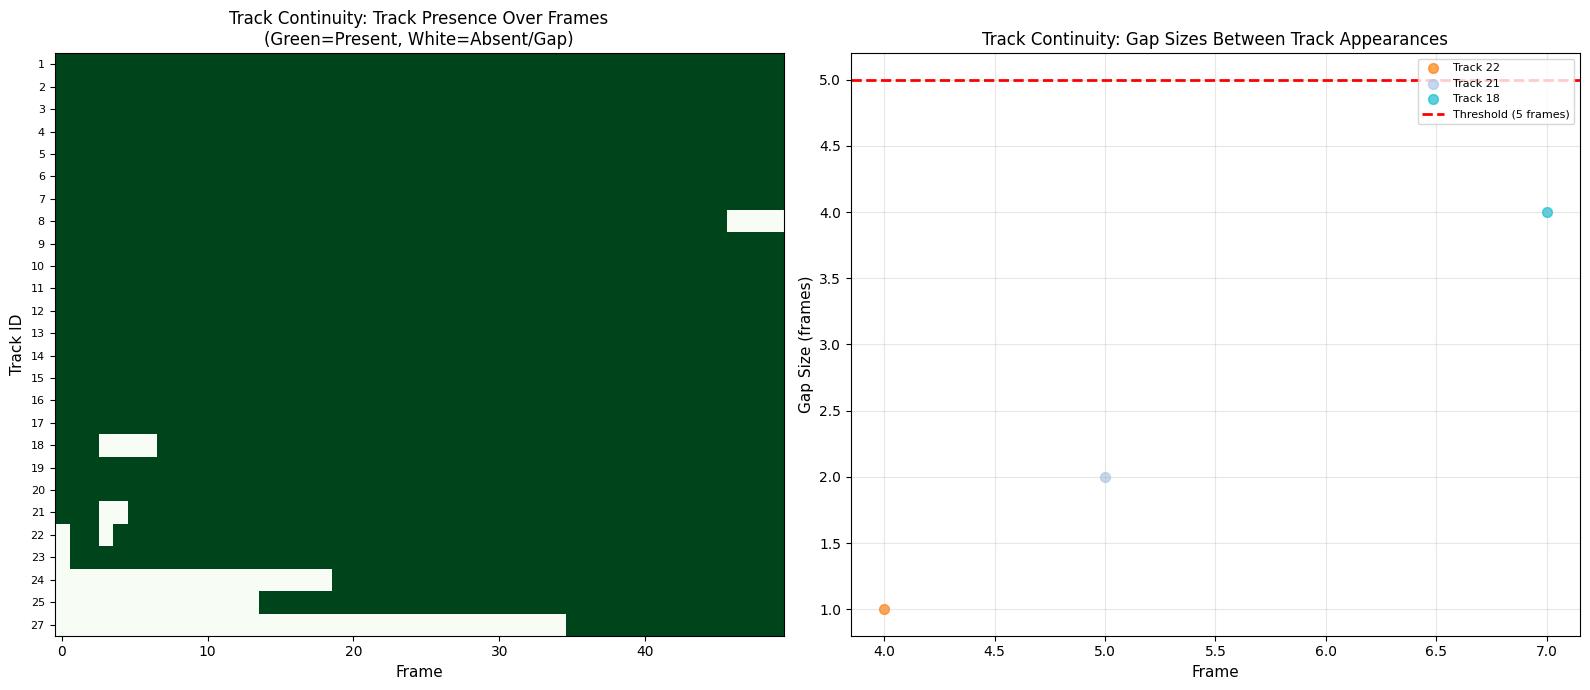

Saved: assertion_4_continuity.png


In [46]:
# Track Continuity Assertion Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Track presence over frames (heatmap style)
ax1 = axes[0]

# Build track presence matrix
unique_tracks = sorted(set(int(t[4]) for fd in all_frame_data for t in fd['tracks']))
presence_matrix = np.zeros((len(unique_tracks), len(all_frame_data)))

for frame_idx, frame_data in enumerate(all_frame_data):
    for track in frame_data['tracks']:
        track_id = int(track[4])
        if track_id in unique_tracks:
            row = unique_tracks.index(track_id)
            presence_matrix[row, frame_idx] = 1

# Only show tracks with >5 frames
active_tracks = [i for i, row in enumerate(presence_matrix) if np.sum(row) > 5]
if active_tracks:
    filtered_matrix = presence_matrix[active_tracks, :]
    filtered_ids = [unique_tracks[i] for i in active_tracks]
    
    ax1.imshow(filtered_matrix, aspect='auto', cmap='Greens', interpolation='nearest')
    ax1.set_xlabel('Frame', fontsize=11)
    ax1.set_ylabel('Track ID', fontsize=11)
    ax1.set_yticks(range(len(filtered_ids)))
    ax1.set_yticklabels(filtered_ids, fontsize=8)
    ax1.set_title('Track Continuity: Track Presence Over Frames\n(Green=Present, White=Absent/Gap)', fontsize=12)

# Right: Gap sizes for tracks
ax2 = axes[1]
if assertions['continuity'].results:
    by_track = assertions['continuity'].get_values_by_track()
    for track_id, values in by_track.items():
        frames = [v[0] for v in values]
        gaps = [v[1] for v in values]
        color = colors[track_id % 20]
        ax2.scatter(frames, gaps, color=color, alpha=0.7, s=50, label=f'Track {track_id}')
    
    ax2.axhline(y=5, color='red', linestyle='--', linewidth=2, label='Threshold (5 frames)')
    ax2.set_xlabel('Frame', fontsize=11)
    ax2.set_ylabel('Gap Size (frames)', fontsize=11)
    ax2.set_title('Track Continuity: Gap Sizes Between Track Appearances', fontsize=12)
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'No gaps detected!\nAll tracks are continuous.', 
             ha='center', va='center', fontsize=14, transform=ax2.transAxes)
    ax2.set_title('Track Continuity: No Gaps Detected', fontsize=12)

plt.tight_layout()
plt.savefig('assertion_4_continuity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: assertion_4_continuity.png")

---
## Assertion 5: Detection Stability Assertion Visualization

### Rule
Detection count shouldn't vary more than **50%** between consecutive frames.

### Significance
- **Scene Stability**: In typical video, objects enter/exit gradually—sudden count changes are suspicious
- **Detector Reliability**: Wildly varying counts indicate detector flickering or sensitivity to lighting
- **Use Case**: Important for crowd monitoring, traffic analysis, and anomaly detection

### Visualization
- **Left Panel**: Bar chart of detection count per frame with mean line and ±50% range
- **Right Panel**: Frame-to-frame count change percentage (green=pass, red=fail)

---

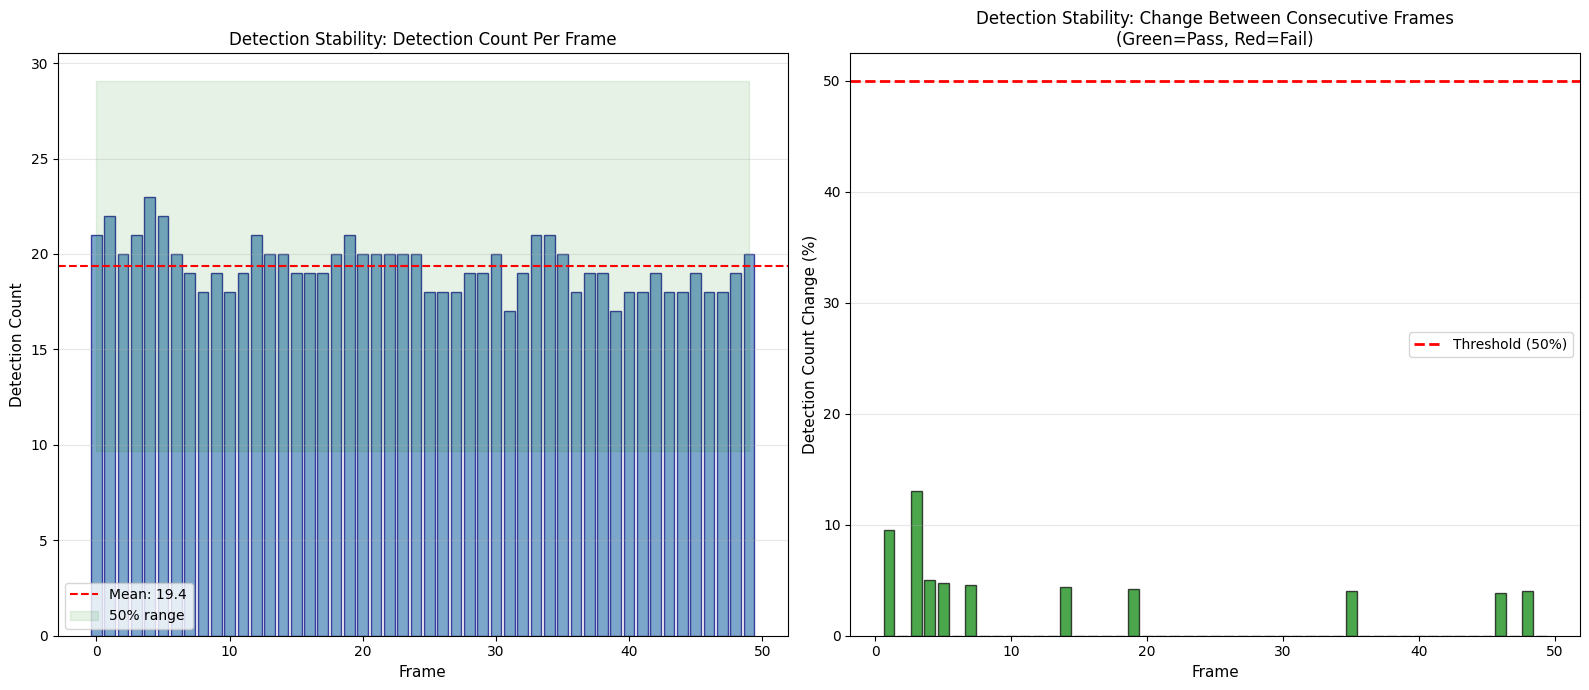

Saved: assertion_5_stability.png


In [47]:
# Detection Stability Assertion Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Detection count over frames
ax1 = axes[0]
frames = range(len(detections_per_frame))
ax1.bar(frames, detections_per_frame, color='steelblue', alpha=0.7, edgecolor='navy')
ax1.axhline(y=np.mean(detections_per_frame), color='red', linestyle='--', 
            label=f'Mean: {np.mean(detections_per_frame):.1f}')
ax1.fill_between(frames, 
                 np.mean(detections_per_frame) * 0.5, 
                 np.mean(detections_per_frame) * 1.5,
                 color='green', alpha=0.1, label='50% range')
ax1.set_xlabel('Frame', fontsize=11)
ax1.set_ylabel('Detection Count', fontsize=11)
ax1.set_title('Detection Stability: Detection Count Per Frame', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Right: Detection count change percentage
ax2 = axes[1]
stability_frames = [r.frame_id for r in assertions['stability'].results]
stability_values = [r.value * 100 for r in assertions['stability'].results]

# Color bars by pass/fail
colors_bar = ['green' if v <= 50 else 'red' for v in stability_values]
ax2.bar(stability_frames, stability_values, color=colors_bar, alpha=0.7, edgecolor='black')
ax2.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Threshold (50%)')
ax2.set_xlabel('Frame', fontsize=11)
ax2.set_ylabel('Detection Count Change (%)', fontsize=11)
ax2.set_title('Detection Stability: Change Between Consecutive Frames\n(Green=Pass, Red=Fail)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('assertion_5_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: assertion_5_stability.png")

---
## Assertion 6: IoU Consistency Assertion Visualization

### Rule
Same track's bounding box IoU (Intersection over Union) must be ≥ **0.3** between consecutive frames.

### Significance
- **Spatial Consistency**: If it's the same object, bounding boxes should overlap significantly
- **Tracking Quality**: Low IoU indicates either rapid movement or tracking drift
- **Use Case**: Validates that track IDs correspond to spatially consistent objects

### IoU Formula
```
IoU = (Area of Intersection) / (Area of Union)
```
- IoU = 1.0: Perfect overlap (identical boxes)
- IoU = 0.3: Reasonable overlap for moving objects
- IoU = 0.0: No overlap (boxes don't intersect)

### Visualization
- **Left Panel**: Current frame boxes (solid) vs. previous frame boxes (dashed) for same tracks
- **Right Panel**: IoU values per track over time, with 0.3 threshold line

---

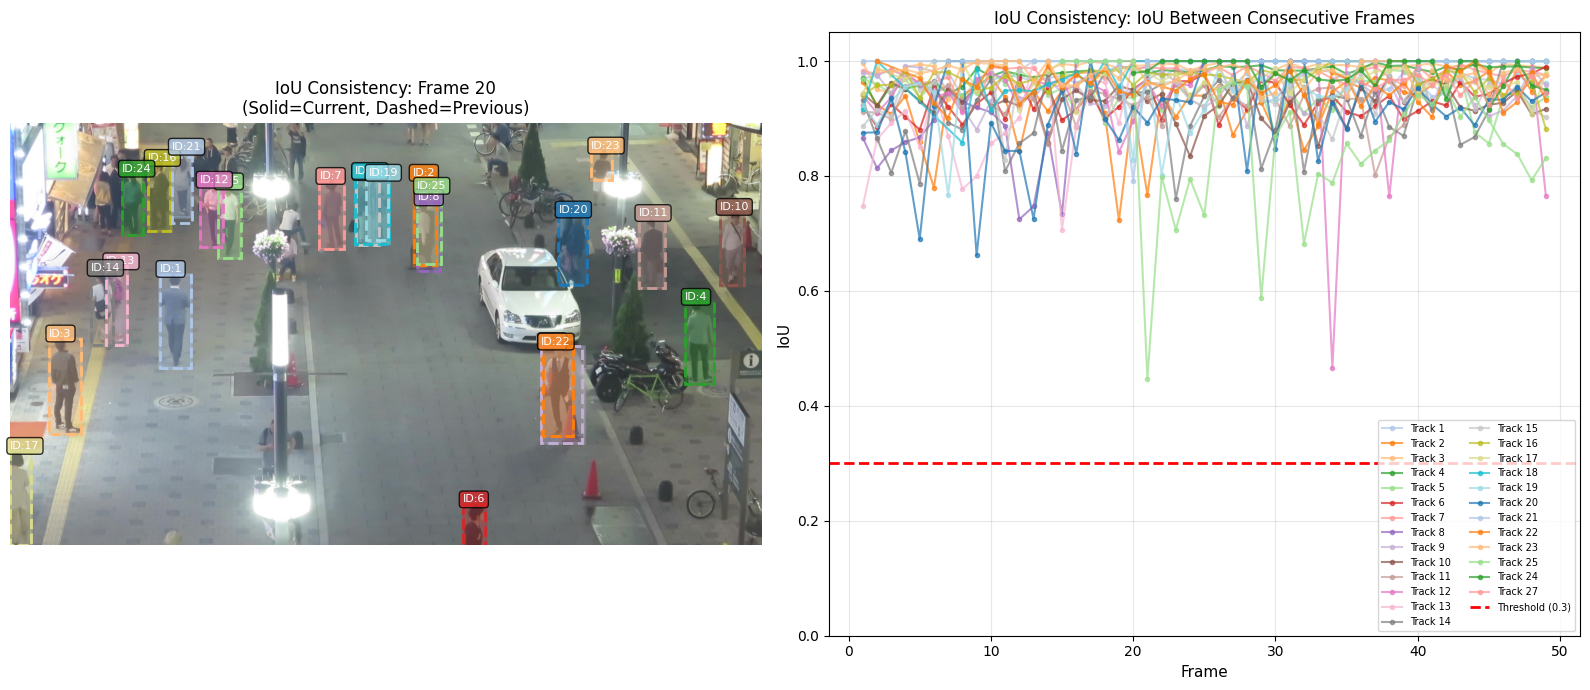

Saved: assertion_6_iou.png


In [48]:
# IoU Consistency Assertion Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Show overlapping bboxes from consecutive frames
ax1 = axes[0]
frame_idx = 20
ax1.imshow(all_frame_data[frame_idx]['image'])

# Draw current frame bboxes (solid)
for track in all_frame_data[frame_idx]['tracks']:
    x1, y1, x2, y2, track_id, conf = track
    color = colors[int(track_id) % 20]
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, 
                              edgecolor=color, facecolor=color, alpha=0.3)
    ax1.add_patch(rect)
    ax1.text(x1, y1-5, f'ID:{int(track_id)}', color='white', fontsize=8,
             bbox=dict(boxstyle='round', facecolor=color, alpha=0.8))

# Draw previous frame bboxes (dashed)
if frame_idx > 0:
    for track in all_frame_data[frame_idx-1]['tracks']:
        x1, y1, x2, y2, track_id, conf = track
        color = colors[int(track_id) % 20]
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, 
                                  edgecolor=color, facecolor='none', linestyle='--')
        ax1.add_patch(rect)

ax1.set_title(f'IoU Consistency: Frame {frame_idx}\n(Solid=Current, Dashed=Previous)', fontsize=12)
ax1.axis('off')

# Right: IoU values per track over frames
ax2 = axes[1]
by_track = assertions['iou'].get_values_by_track()
for track_id, values in by_track.items():
    if len(values) > 3:
        frames = [v[0] for v in values]
        ious = [v[1] for v in values]
        color = colors[track_id % 20]
        ax2.plot(frames, ious, '-o', color=color, alpha=0.7, markersize=3, label=f'Track {track_id}')

ax2.axhline(y=0.3, color='red', linestyle='--', linewidth=2, label='Threshold (0.3)')
ax2.set_xlabel('Frame', fontsize=11)
ax2.set_ylabel('IoU', fontsize=11)
ax2.set_title('IoU Consistency: IoU Between Consecutive Frames', fontsize=12)
ax2.legend(loc='lower right', fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('assertion_6_iou.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: assertion_6_iou.png")

---
## T2: Optimization Problem (INFaaS-based)

### Reference
Francisco Romero et al. **"INFaaS: Automated Model-less Inference Serving"** (USENIX ATC 2021)

### What is INFaaS?

INFaaS is an **automated model-less inference serving system** that abstracts away model selection from users. Instead of users specifying which model to use, they specify **performance requirements (SLAs)**, and INFaaS automatically selects the optimal model configuration.

### The Optimization Problem

We formulate model selection as an **Integer Linear Programming (ILP)** problem to find the optimal configuration that minimizes cost while meeting SLA constraints.

---

### Variable Notation

| Symbol | Type | Description |
|--------|------|-------------|
| **V** (capital) | Set | Set of all model variants: {yolov8n, yolov8s, yolov8m, yolov8l} |
| **v** (lowercase) | Element | A specific model variant, v ∈ V |
| **B** (capital) | Set | Set of batch sizes: {1, 2, 4, 8} |
| **b** (lowercase) | Element | A specific batch size, b ∈ B |
| **R** (capital) | Set | Set of replica counts: {1, 2, ..., 10} |
| **r** (lowercase) | Element | A specific replica count, r ∈ R |
| **x_{v,b,r}** | Decision Variable | Binary (0 or 1): 1 if configuration (v, b, r) is selected |
| **C_v** | Parameter | Cost per replica for variant v |
| **L_base(v)** | Parameter | Base latency (ms) for variant v with batch=1, replicas=1 |
| **A(v)** | Parameter | Accuracy of variant v |

### Why These Variables?

- **Model Variants (V)**: Different model sizes trade off accuracy vs. speed. YOLOv8n is fastest but least accurate; YOLOv8l is slowest but most accurate.
- **Batch Size (B)**: Processing multiple frames together improves throughput but increases latency.
- **Replicas (R)**: Running multiple model instances in parallel increases throughput and reduces latency under load.

---

In [49]:
print("\n" + "=" * 80)
print("T2: OPTIMIZATION PROBLEM (INFaaS-based)")
print("=" * 80)

print("""
OPTIMIZATION PROBLEM FORMULATION:

DECISION VARIABLES:
  x_v,b,r in {0, 1}  for v in V, b in B, r in R
  Where:
    V = {yolov8n, yolov8s, yolov8m, yolov8l}  (model variants)
    B = {1, 2, 4, 8}  (batch sizes)
    R = {1, 2, ..., 10}  (replicas)

OBJECTIVE:
  Minimize: sum(x_v,b,r * Cost(v, r))
  Where Cost(v, r) = C_v * r

CONSTRAINTS:
  1. sum(x_v,b,r) = 1  (exactly one configuration)
  2. Latency(v,b,r) <= 500ms
  3. Throughput(v,b,r) >= 20 fps
  4. Accuracy(v) >= 0.75
  5. Cost(v,r) <= 20

LATENCY MODEL:
  L(v,b,r) = L_base(v) * (1 + 0.3*log2(b)) / sqrt(r)

THROUGHPUT MODEL:
  T(v,b,r) = (1000/L_base(v)) * b * r * 0.8
""")

@dataclass
class SLA:
    max_latency_ms: float = 500.0
    min_throughput_fps: float = 20.0
    min_accuracy: float = 0.75
    max_cost: float = 20.0

# Model profiles (using measured accuracy)
MODEL_PROFILES = {
    'yolov8n': {'base_latency_ms': 170, 'accuracy': accuracy['combined_accuracy'], 'cost': 1.0},
    'yolov8s': {'base_latency_ms': 400, 'accuracy': 0.85, 'cost': 2.0},
    'yolov8m': {'base_latency_ms': 900, 'accuracy': 0.86, 'cost': 3.0},
    'yolov8l': {'base_latency_ms': 1700, 'accuracy': 0.87, 'cost': 4.0}
}

print("Model Profiles:")
print(f"{'Variant':<12} {'Latency(ms)':<15} {'Accuracy':<12} {'Cost/Rep'}")
print("-" * 50)
for name, profile in MODEL_PROFILES.items():
    print(f"{name:<12} {profile['base_latency_ms']:<15} {profile['accuracy']:<12.4f} {profile['cost']}")


T2: OPTIMIZATION PROBLEM (INFaaS-based)

OPTIMIZATION PROBLEM FORMULATION:

DECISION VARIABLES:
  x_v,b,r in {0, 1}  for v in V, b in B, r in R
  Where:
    V = {yolov8n, yolov8s, yolov8m, yolov8l}  (model variants)
    B = {1, 2, 4, 8}  (batch sizes)
    R = {1, 2, ..., 10}  (replicas)

OBJECTIVE:
  Minimize: sum(x_v,b,r * Cost(v, r))
  Where Cost(v, r) = C_v * r

CONSTRAINTS:
  1. sum(x_v,b,r) = 1  (exactly one configuration)
  2. Latency(v,b,r) <= 500ms
  3. Throughput(v,b,r) >= 20 fps
  4. Accuracy(v) >= 0.75
  5. Cost(v,r) <= 20

LATENCY MODEL:
  L(v,b,r) = L_base(v) * (1 + 0.3*log2(b)) / sqrt(r)

THROUGHPUT MODEL:
  T(v,b,r) = (1000/L_base(v)) * b * r * 0.8

Model Profiles:
Variant      Latency(ms)     Accuracy     Cost/Rep
--------------------------------------------------
yolov8n      170             0.8607       1.0
yolov8s      400             0.8500       2.0
yolov8m      900             0.8600       3.0
yolov8l      1700            0.8700       4.0


---
## T3: Optimizer Implementation

### Two Optimization Approaches

We implement two complementary optimization strategies:

1. **Rule-Based Optimizer**: Fast, heuristic-based approach using domain knowledge
2. **ILP Optimizer**: Optimal solution using Integer Linear Programming (PuLP library)

---

### Mathematical Formulation

#### Decision Variables
```
x_{v,b,r} ∈ {0, 1}   for all v ∈ V, b ∈ B, r ∈ R
```
Where x_{v,b,r} = 1 means we select variant v with batch size b and r replicas.

#### Objective Function
```
Minimize: Σ x_{v,b,r} × C_v × r
```
Minimize total cost (cost per variant × number of replicas).

#### Constraints

| Constraint | Formula | Meaning |
|------------|---------|---------|
| **Exactly one config** | Σ x_{v,b,r} = 1 | Select exactly one configuration |
| **Latency SLA** | L(v,b,r) ≤ L_max | Latency must be under max threshold |
| **Throughput SLA** | T(v,b,r) ≥ T_min | Throughput must meet minimum requirement |
| **Accuracy SLA** | A(v) ≥ A_min | Model accuracy must be acceptable |
| **Cost Budget** | C(v,r) ≤ C_max | Total cost must be within budget |

#### Performance Models

**Latency Model:**
```
L(v, b, r) = L_base(v) × (1 + 0.3 × log₂(b)) / √r
```
- Latency increases with batch size (log factor)
- Latency decreases with replicas (square root factor due to load balancing)

**Throughput Model:**
```
T(v, b, r) = (1000 / L_base(v)) × b × r × 0.8
```
- Throughput scales linearly with batch size and replicas
- 0.8 factor accounts for overhead (scheduling, memory transfers)

---

### Rule-Based Optimizer Strategy

The rule-based optimizer uses **load-aware heuristics**:

| Load Level | Strategy | Rationale |
|------------|----------|-----------|
| **Low (< 0.5)** | Maximize accuracy, then minimize cost | Resources available, prioritize quality |
| **Normal (0.5-1.5)** | Minimize cost, then maximize accuracy | Balance efficiency and quality |
| **High (> 1.5)** | Maximize throughput, then minimize latency | Must keep up with demand |

---

In [50]:
print("\n" + "=" * 80)
print("T3: OPTIMIZER IMPLEMENTATION")
print("=" * 80)

class Optimizer:
    def __init__(self, profiles, sla):
        self.profiles = profiles
        self.sla = sla
        self.batch_sizes = [1, 2, 4, 8]
        self.max_replicas = 10

    def get_latency(self, base_latency, batch, replicas):
        return base_latency * (1 + 0.3 * np.log2(max(1, batch))) / np.sqrt(max(1, replicas))

    def get_throughput(self, base_latency, batch, replicas):
        return (1000 / base_latency) * batch * replicas * 0.8

    def generate_configs(self):
        configs = []
        for name, profile in self.profiles.items():
            for batch in self.batch_sizes:
                for replicas in range(1, self.max_replicas + 1):
                    lat = self.get_latency(profile['base_latency_ms'], batch, replicas)
                    thr = self.get_throughput(profile['base_latency_ms'], batch, replicas)
                    cost = profile['cost'] * replicas
                    configs.append({
                        'variant': name, 'batch': batch, 'replicas': replicas,
                        'latency': lat, 'throughput': thr, 'accuracy': profile['accuracy'], 'cost': cost,
                        'sla_ok': lat <= self.sla.max_latency_ms and thr >= self.sla.min_throughput_fps and 
                                  profile['accuracy'] >= self.sla.min_accuracy and cost <= self.sla.max_cost
                    })
        return configs

    def solve_rule_based(self, load=1.0):
        configs = [c for c in self.generate_configs() if c['sla_ok']]
        if not configs:
            return None
        if load < 0.5:
            return sorted(configs, key=lambda c: (-c['accuracy'], c['cost']))[0]
        elif load > 1.5:
            return sorted(configs, key=lambda c: (-c['throughput'], c['latency']))[0]
        else:
            return sorted(configs, key=lambda c: (c['cost'], -c['accuracy']))[0]

    def solve_ilp(self, objective='min_cost'):
        if not PULP_AVAILABLE:
            return self.solve_rule_based()
        
        configs = self.generate_configs()
        prob = LpProblem("Optimizer", LpMinimize if objective == 'min_cost' else LpMaximize)
        x = [LpVariable(f"x_{i}", cat=LpBinary) for i in range(len(configs))]
        
        prob += lpSum(x) == 1
        prob += lpSum(x[i] * configs[i]['latency'] for i in range(len(configs))) <= self.sla.max_latency_ms
        prob += lpSum(x[i] * configs[i]['throughput'] for i in range(len(configs))) >= self.sla.min_throughput_fps
        prob += lpSum(x[i] * configs[i]['accuracy'] for i in range(len(configs))) >= self.sla.min_accuracy
        prob += lpSum(x[i] * configs[i]['cost'] for i in range(len(configs))) <= self.sla.max_cost
        
        if objective == 'min_cost':
            prob += lpSum(x[i] * configs[i]['cost'] for i in range(len(configs)))
        else:
            prob += lpSum(x[i] * configs[i]['accuracy'] for i in range(len(configs)))
        
        prob.solve(PULP_CBC_CMD(msg=0))
        
        if LpStatus[prob.status] == 'Optimal':
            for i in range(len(configs)):
                if value(x[i]) == 1:
                    return configs[i]
        return None

sla = SLA()
optimizer = Optimizer(MODEL_PROFILES, sla)

print("\nRule-Based Optimizer Results:")
print("-" * 80)
for load in [0.3, 1.0, 2.0]:
    result = optimizer.solve_rule_based(load)
    if result:
        print(f"Load={load}: {result['variant']}, batch={result['batch']}, replicas={result['replicas']}, cost={result['cost']:.1f}")

if PULP_AVAILABLE:
    print("\nILP Optimizer Results:")
    print("-" * 80)
    for obj in ['min_cost', 'max_accuracy']:
        result = optimizer.solve_ilp(obj)
        if result:
            print(f"{obj}: {result['variant']}, batch={result['batch']}, replicas={result['replicas']}, cost={result['cost']:.1f}")


T3: OPTIMIZER IMPLEMENTATION

Rule-Based Optimizer Results:
--------------------------------------------------------------------------------
Load=0.3: yolov8n, batch=8, replicas=1, cost=1.0
Load=1.0: yolov8n, batch=8, replicas=1, cost=1.0
Load=2.0: yolov8n, batch=8, replicas=10, cost=10.0

ILP Optimizer Results:
--------------------------------------------------------------------------------
min_cost: yolov8n, batch=8, replicas=1, cost=1.0
max_accuracy: yolov8n, batch=8, replicas=10, cost=10.0


---
## T4: Agentic Framework

### What is an Agentic Optimizer?

An agentic optimizer is an **autonomous decision-making system** that continuously monitors the pipeline and makes real-time adjustments. Unlike static optimizers that run once, agentic systems operate in a **feedback loop**, adapting to changing conditions.

### The Observe-Think-Act Paradigm

The agentic framework follows a classic AI agent architecture:

```
┌─────────────────────────────────────────────────────────────┐
│                    AGENTIC OPTIMIZER                         │
│                                                              │
│    ┌──────────┐      ┌──────────┐      ┌──────────┐        │
│    │ OBSERVE  │ ───► │  THINK   │ ───► │   ACT    │        │
│    └──────────┘      └──────────┘      └──────────┘        │
│         │                                    │               │
│         │                                    │               │
│         └◄───────────────────────────────────┘               │
│                    (feedback loop)                           │
└─────────────────────────────────────────────────────────────┘
```

---

### Phase Descriptions

| Phase | Function | Inputs | Outputs |
|-------|----------|--------|---------|
| **OBSERVE** | Collect runtime metrics | Pipeline execution | load, latency, throughput |
| **THINK** | Analyze & decide | Current metrics + history | action recommendation |
| **ACT** | Execute changes | Decision from Think | New configuration |

### Detailed Phase Breakdown

#### 1. OBSERVE Phase
- Collects current **load factor** (request rate / capacity)
- Measures actual **latency** from recent requests
- Maintains a **sliding window** of historical metrics (last 10 observations)

#### 2. THINK Phase
- **Load Prediction**: Uses weighted moving average to predict future load
  ```
  predicted_load = mean(recent_loads) + 0.1 × (current - oldest)
  ```
- **SLA Check**: Verifies if current latency exceeds threshold
- **Decision Logic**:
  - If SLA violated → `reconfigure_urgent`
  - If load changing rapidly (>30%) → `reconfigure_proactive`
  - Otherwise → `maintain` current configuration

#### 3. ACT Phase
- For **urgent** reconfiguration: Uses ILP for optimal solution
- For **proactive** reconfiguration: Uses rule-based optimizer (faster)
- For **maintain**: No action taken, continue monitoring

### Why Agentic?

1. **Adaptability**: Responds to workload changes in real-time
2. **Proactive**: Anticipates problems before SLA violations
3. **Efficiency**: Only reconfigures when necessary
4. **Autonomous**: Requires no human intervention during operation

---

In [51]:
print("\n" + "=" * 80)
print("T4: AGENTIC FRAMEWORK")
print("=" * 80)

print("""
AGENTIC OPTIMIZER ARCHITECTURE:

    +-------------------------------------------+
    |           AGENTIC OPTIMIZER               |
    |   +--------+   +--------+   +--------+   |
    |   |OBSERVE |-->| THINK  |-->|  ACT   |   |
    |   +--------+   +--------+   +--------+   |
    |       ^                          |        |
    |       +<-------------------------+        |
    +-------------------------------------------+

OBSERVE: Collect metrics (latency, throughput, load)
THINK: Predict load, check SLA, decide action
ACT: Reconfigure pipeline if needed
""")

class AgenticOptimizer:
    def __init__(self, optimizer):
        self.optimizer = optimizer
        self.load_history = deque(maxlen=10)
        self.current_config = None
        self.decisions = []

    def observe(self, load, latency):
        self.load_history.append(load)
        return {'load': load, 'latency': latency}

    def think(self, observation):
        if len(self.load_history) >= 3:
            predicted_load = np.mean(list(self.load_history)[-3:]) + 0.1 * (list(self.load_history)[-1] - list(self.load_history)[-3])
        else:
            predicted_load = observation['load']
        
        sla_ok = observation['latency'] <= self.optimizer.sla.max_latency_ms
        load_change = abs(predicted_load - observation['load']) / (observation['load'] + 0.1)
        
        if not sla_ok:
            action = 'reconfigure_urgent'
        elif load_change > 0.3:
            action = 'reconfigure_proactive'
        else:
            action = 'maintain'
        
        return {'predicted_load': predicted_load, 'sla_ok': sla_ok, 'action': action}

    def act(self, analysis):
        if analysis['action'] == 'maintain':
            return None
        
        if analysis['action'] == 'reconfigure_urgent' and PULP_AVAILABLE:
            new_config = self.optimizer.solve_ilp('min_cost')
        else:
            new_config = self.optimizer.solve_rule_based(analysis['predicted_load'])
        
        if new_config:
            self.current_config = new_config
            self.decisions.append({'analysis': analysis, 'config': new_config})
        return new_config

    def run_cycle(self, load, latency):
        obs = self.observe(load, latency)
        analysis = self.think(obs)
        new_config = self.act(analysis)
        return {'analysis': analysis, 'changed': new_config is not None}

# Run simulation
agent = AgenticOptimizer(optimizer)
agent.current_config = optimizer.solve_rule_based(1.0)

print("\nAgentic Optimizer Simulation:")
print("-" * 70)
print(f"{'Step':<6} {'Load':<8} {'Latency':<12} {'Action':<25} {'Config'}")
print("-" * 70)

scenarios = [(1.0, 150), (1.2, 180), (1.8, 280), (2.2, 350), (1.5, 200), (0.8, 120)]
for i, (load, latency) in enumerate(scenarios):
    result = agent.run_cycle(load, latency)
    config_str = agent.current_config['variant'] if agent.current_config else 'None'
    print(f"{i+1:<6} {load:<8.1f} {latency:<12}ms {result['analysis']['action']:<25} {config_str}")

print(f"\nTotal decisions made: {len(agent.decisions)}")


T4: AGENTIC FRAMEWORK

AGENTIC OPTIMIZER ARCHITECTURE:

    +-------------------------------------------+
    |           AGENTIC OPTIMIZER               |
    |   +--------+   +--------+   +--------+   |
    |   |OBSERVE |-->| THINK  |-->|  ACT   |   |
    |   +--------+   +--------+   +--------+   |
    |       ^                          |        |
    |       +<-------------------------+        |
    +-------------------------------------------+

OBSERVE: Collect metrics (latency, throughput, load)
THINK: Predict load, check SLA, decide action
ACT: Reconfigure pipeline if needed


Agentic Optimizer Simulation:
----------------------------------------------------------------------
Step   Load     Latency      Action                    Config
----------------------------------------------------------------------
1      1.0      150         ms maintain                  yolov8n
2      1.2      180         ms maintain                  yolov8n
3      1.8      280         ms maintain     

---
## Summary and Save Results

---

In [2]:
# Save all results
results = {
    'T1_accuracy': {
        'detection': accuracy['detection']['accuracy'],
        'tracking': accuracy['tracking']['accuracy'],
        'consistency': accuracy['consistency']['accuracy'],
        'combined': accuracy['combined_accuracy']
    },
    'assertions': {
        name: {
            'total': len(a.results),
            'passed': sum(1 for r in a.results if r.passed),
            'failed': len(a.violations),
            'pass_rate': a.get_pass_rate()
        } for name, a in assertions.items()
    },
    'T3_optimization': {
        'rule_based_low_load': optimizer.solve_rule_based(0.3),
        'rule_based_normal': optimizer.solve_rule_based(1.0),
        'rule_based_high_load': optimizer.solve_rule_based(2.0)
    },
    'T4_agentic_decisions': len(agent.decisions)
}

with open('milestone3_complete_results.json', 'w') as f:
    json.dump(results, f, indent=2, default=str)

print("\n" + "=" * 80)
print("MILESTONE 3 COMPLETE!")
print("=" * 80)
print("\nFiles Generated:")
print("- assertion_1_distance.png")
print("- assertion_2_bbox_size.png")
print("- assertion_3_confidence.png")
print("- assertion_4_continuity.png")
print("- assertion_5_stability.png")
print("- assertion_6_iou.png")
print("- milestone3_complete_results.json")
print(f"\nT1 Combined Accuracy: {accuracy['combined_accuracy']:.4f}")
print(f"Overall Assertion Pass Rate: {passed_all/total_all*100:.1f}%")

NameError: name 'accuracy' is not defined